# Confidence Intervals and Bootstrap

## Objective

Estimate 95% confidence intervals for the means of `age`, `absences`, `G1`, `G2`, and `G3`, then compare traditional standard-error intervals with percentile bootstrap intervals.

## Hypotheses and assumptions

Confidence intervals estimate plausible population means rather than directly testing a null hypothesis. Traditional intervals assume independent observations and an approximately normal sampling distribution of the mean. The variables, especially grades and absences, are non-normal, but the large sample supports the Central Limit Theorem. Bootstrap intervals assume the observed sample is representative and observations are independent.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_processed_data
from src.statistics import StatisticalAnalyzer

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_processed_data()
analyzer = StatisticalAnalyzer(df)

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully
Rows: 649
Columns: 33


## Calculate traditional and bootstrap intervals

Ten thousand resamples and a fixed random seed are used so results are reproducible across runs.

In [2]:
confidence_columns = list(analyzer.numeric_cols)

comparison_rows = []

for column in confidence_columns:
    traditional = analyzer.confidence_interval(
        column,
        confidence=0.95
    )

    bootstrap = analyzer.bootstrap_ci(
        column,
        n_bootstrap=10000,
        confidence=0.95,
        random_seed=42
    )

    comparison_rows.append({
        "column": column,
        "mean": traditional["mean"],
        "ci_lower": traditional["lower_bound"],
        "ci_upper": traditional["upper_bound"],
        "bootstrap_lower": bootstrap["lower_bound"],
        "bootstrap_upper": bootstrap["upper_bound"],
        "ci_width": (
            traditional["upper_bound"]
            - traditional["lower_bound"]
        ),
        "bootstrap_width": (
            bootstrap["upper_bound"]
            - bootstrap["lower_bound"]
        )
    })

comparison_df = pd.DataFrame(comparison_rows)

print(comparison_df.round(3))

        column    mean  ci_lower  ci_upper  bootstrap_lower  bootstrap_upper  \
0          age  16.744    16.651    16.838           16.652           16.840   
1         Medu   2.515     2.427     2.602            2.430            2.602   
2         Fedu   2.307     2.222     2.391            2.222            2.393   
3   traveltime   1.569     1.511     1.626            1.512            1.627   
4    studytime   1.931     1.867     1.994            1.866            1.994   
5     failures   0.222     0.176     0.268            0.177            0.270   
6       famrel   3.931     3.857     4.004            3.857            4.005   
7     freetime   3.180     3.099     3.261            3.100            3.260   
8        goout   3.185     3.094     3.275            3.094            3.276   
9         Dalc   1.502     1.431     1.573            1.435            1.576   
10        Walc   2.280     2.182     2.379            2.183            2.379   
11      health   3.536     3.425     3.6

## Results

Traditional and bootstrap intervals are nearly identical for all five variables. For `G3`, the traditional 95% interval is 11.657-12.155 and the bootstrap interval is 11.652-12.151. Their close agreement suggests stable mean estimates despite non-normal raw grades.

In [3]:
confidence_output_file = (
    REPORTS_DIR
    / "ci_comparison.csv"
)

comparison_df.to_csv(
    confidence_output_file,
    index=False
)

print("Saved to:", confidence_output_file)

Saved to: C:\Users\KMZ\Projects\CSX2003\Statistics-superstars\reports\ci_comparison.csv


## Visual comparison

The plot compares interval centers and widths. Blue marks show traditional intervals and green marks show bootstrap intervals.

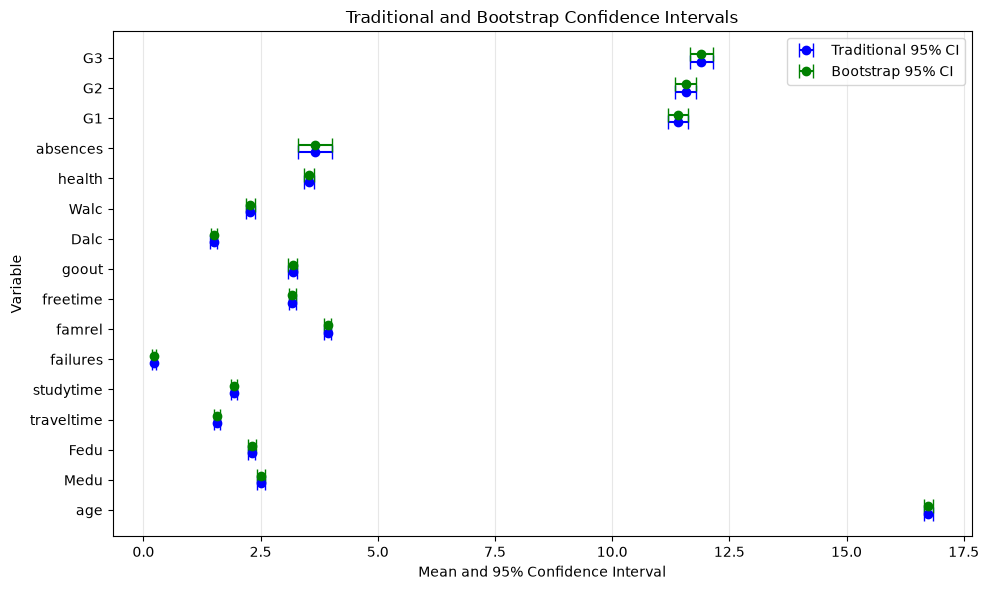

Saved to: C:\Users\KMZ\Projects\CSX2003\Statistics-superstars\reports\figures\confidence_intervals_comparison.png


In [4]:
positions = np.arange(len(comparison_df))
offset = 0.12

traditional_lower_error = (
    comparison_df["mean"]
    - comparison_df["ci_lower"]
)

traditional_upper_error = (
    comparison_df["ci_upper"]
    - comparison_df["mean"]
)

bootstrap_lower_error = (
    comparison_df["mean"]
    - comparison_df["bootstrap_lower"]
)

bootstrap_upper_error = (
    comparison_df["bootstrap_upper"]
    - comparison_df["mean"]
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    comparison_df["mean"],
    positions - offset,
    xerr=[
        traditional_lower_error,
        traditional_upper_error
    ],
    fmt="o",
    capsize=5,
    color="blue",
    label="Traditional 95% CI"
)

plt.errorbar(
    comparison_df["mean"],
    positions + offset,
    xerr=[
        bootstrap_lower_error,
        bootstrap_upper_error
    ],
    fmt="o",
    capsize=5,
    color="green",
    label="Bootstrap 95% CI"
)

plt.yticks(
    positions,
    comparison_df["column"]
)

plt.xlabel("Mean and 95% Confidence Interval")
plt.ylabel("Variable")
plt.title(
    "Traditional and Bootstrap Confidence Intervals"
)

plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

confidence_figure_file = (
    FIGURES_DIR
    / "confidence_intervals_comparison.png"
)

plt.savefig(
    confidence_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved to:", confidence_figure_file)

## Conclusion

Both approaches lead to the same practical conclusions. Bootstrap intervals are a useful robustness check because the observed variables are discrete and non-normal. Neither method removes possible sampling bias or dependence between observations.